# Man-DC Analysis

In [29]:
# import
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import MDAnalysis as mda
import xarray as arr
import mdtraj as md
import scipy
from MDAnalysis.analysis import distances

In [30]:
# paths to simulations
path1 = "/data/geissler/simulations/dc-sign-2xr5/1_crd_sol_lig/1rep/"  # path to replica1
path2 = "/data/geissler/simulations/dc-sign-2xr5/1_crd_sol_lig/2rep/"  # path to replica2
path3 = "/data/geissler/simulations/dc-sign-2xr5/1_crd_sol_lig/3rep/"  # path to replica3
path_combined = "/data/geissler/simulations/dc-sign-2xr5/1_crd_sol_lig/combined/"  # path to folder with concatenated version of all 3 replicas
path_stats = "/data/geissler/simulations/dc-sign-2xr5/1_crd_sol_lig/combined/stats/"  # path to save results

## RMSD Calcium and Ligand to pocket (Figure S3)

### Cal to pocket

RMSD was calculated with gromacs using the protein backbone as the group for least squares fit and the Calcium atom for the RMSD calculation. The trajectory was centered on the pocket atoms, otherwise the calcium atoms jumps in and out of the box.

In [51]:
# load data
rmsd_cal_center = np.loadtxt(f"{path_stats}cal_center_rmsd.xvg",
                     comments =['#','@'])
rmsd_cal_center[:, 0] = np.arange(0, 15003)
rmsd_lig = np.loadtxt(f"{path_stats}rmsd_lig.xvg",
                     comments =['#','@'])
rmsd_lig[:, 0] = np.arange(0, 15003)

In [52]:
# smooth RMSD over 20 frames
def movingaverage(values, window):
    weights = np.repeat(1.0, window)/window
    sma = np.convolve(values, weights, 'valid')
    return sma
av = 20

In [53]:
rmean_cal = movingaverage(rmsd_cal_center[:,1], av)
rmean_lig = movingaverage(rmsd_lig[:,1], av)

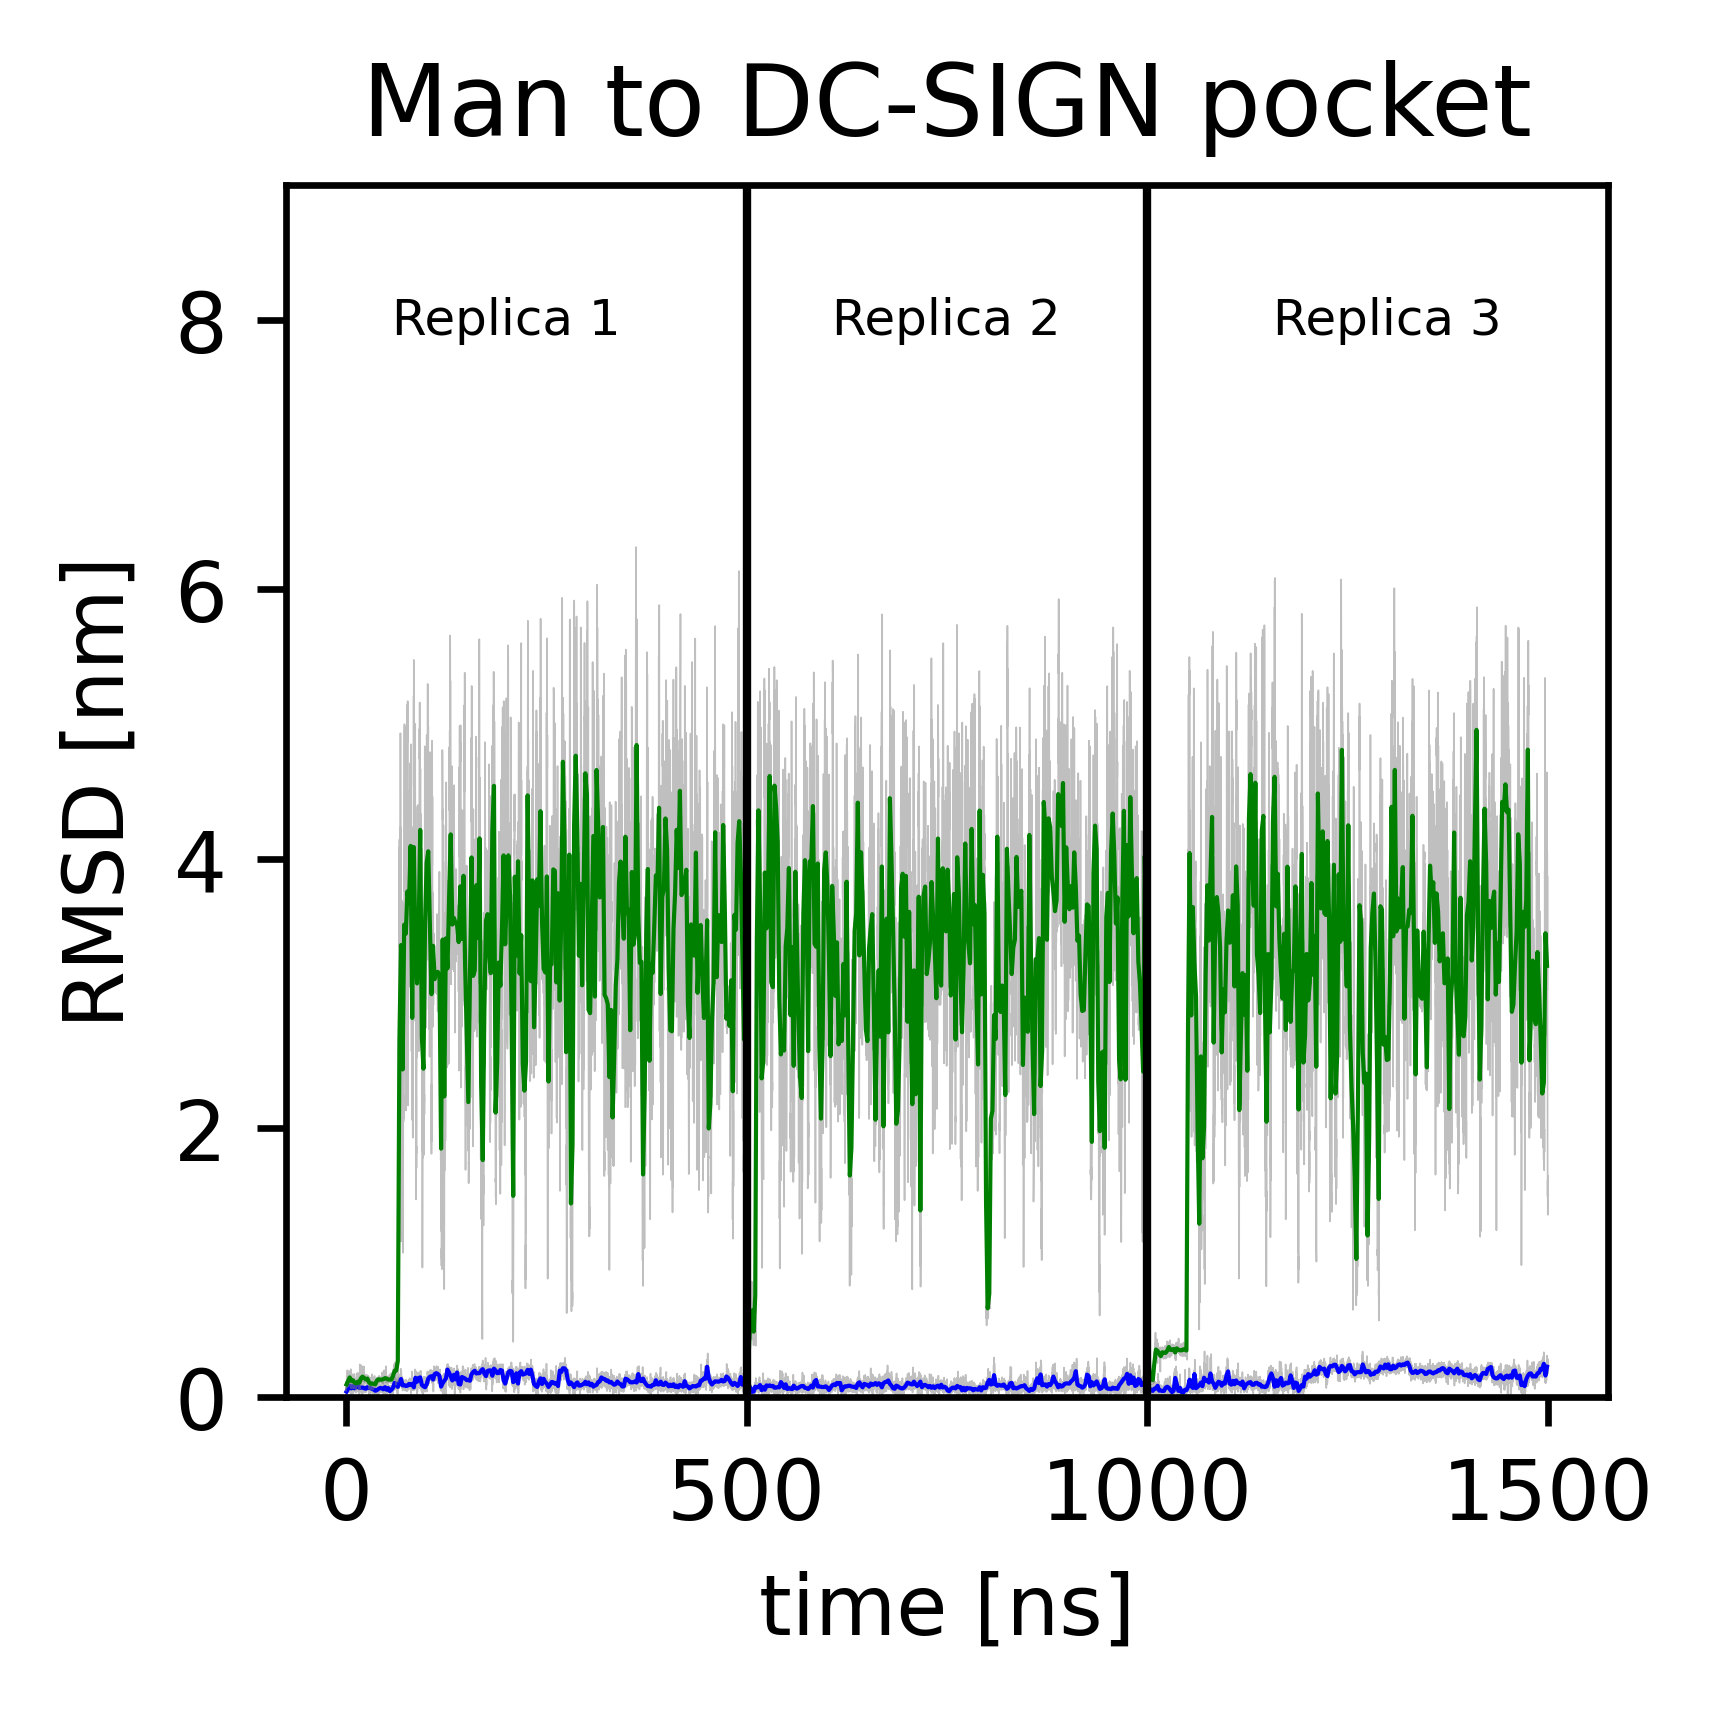

In [56]:
# plot RMSD
cm = 1/2.54
fig, ax = plt.subplots(figsize=(7.5*cm, 7.5*cm), dpi=600)

ax.plot(rmsd_cal_center.T[1], linewidth=0.2, c='grey', alpha=0.5)  # RMSD Cal
ax.plot(rmsd_cal_center[int(av/2-1):-int(av/2),0][::av]/1, rmean_cal[::av], linewidth=0.5, c='#0000FF') # smoothed RMSD Cal
ax.plot(rmsd_lig.T[1], linewidth=0.2, c='grey', alpha=0.5)  # RMSD lig
ax.plot(rmsd_lig[int(av/2-1):-int(av/2),0][::av]/1, rmean_lig[::av], linewidth=0.5, c='green') # smoothed RMSD lig
plt.axvline(5000, color='#000000', linewidth=1)  # borders between replica
plt.axvline(10000, color='#000000', linewidth=1)

plt.text(2000, 8, "Replica 1", size=6, rotation=0.,  # labels
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(7500, 8, "Replica 2", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(13000, 8, "Replica 3", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))

ax.set_ylim(0,9)
# ax.set_xlim(0,15010)
plt.xticks([0, 5000, 10000, 15000,], ['0', '500', '1000', '1500',], fontsize=10)
plt.title('Man to DC-SIGN pocket')
ax.set_xlabel('time [ns]')
ax.set_ylabel('RMSD [nm]')
plt.tight_layout()
# plt.savefig("/data/geissler/analysis/RMSD/cal_lig/man-dc.png")

## identify different binding states

Here I define the different binding conformations ("binding states") by distances of different mannose Hydroxy-groups to different amino acids in the binding pocket of the receptor: 
<br> 
(the different HO-groups are hightlighted in Fig.5 of the paper)
- the "crystal state" is defined by HO4 being close to Glu347, HO3 being close to Glu354, HO6 being far away from Glu358 and HO2 being far away from Glu347
- "state A" is defined by HO2 being close to Glu347, HO4 being far from Glu347, HO6 being far from Glu358 and HO2 being far from Glu354
- "state B" is defined by HO2 being close to Glu354, HO4 being far from Glu347, HO6 being far from Glu358 and HO2 being far from Glu347
- "state C" is defined by HO6 being close to Glu358, HO3 being close to Glu354 and HO2 being far from Glu347 

In [3]:
# for the calculations I concatenated all frames of ligand being bound to the pocket
traj = mda.Universe(path_combined+'md_500ns.pdb',
                   path_combined+'combined_bound.xtc')

As I define the binding states by distances, I calculate the different distances between HO atoms and the respective amino acids

In [4]:
# this calculates the distance between the two defined atoms below for each frame of the simulation and appends them to a list
# distance 1: HO6 to Glutamic Acid 358
man = traj.select_atoms('resname AMAN and name HO6')
prot = traj.select_atoms('protein and resid 358 and name CD') 

distance1 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance1.append(dist_arr/10)  # convert from Angstr. to nm

In [5]:
# distance 2: HO2 to Glutamic Acid 347
man = traj.select_atoms('resname AMAN and name HO2')
prot = traj.select_atoms('protein and resid 347 and name CD')

distance2 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance2.append(dist_arr/10)  # convert from Angstr. to nm

In [6]:
# distance 3: HO3 to Glutamic Acid 354
man = traj.select_atoms('resname AMAN and name HO3')
prot = traj.select_atoms('protein and resid 354 and name CD')

distance3 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance3.append(dist_arr/10)  # convert from Angstr. to nm

In [7]:
# distance 4: HO4 to Glutamic Acid 347 
man = traj.select_atoms('resname AMAN and name HO4')
prot = traj.select_atoms('protein and resid 347 and name CD')

distance4 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance4.append(dist_arr/10)  # convert from Angstr. to nm

In [8]:
# distance 5: HO2 to Glutamic Acid 354
man = traj.select_atoms('resname AMAN and name HO2')  
prot = traj.select_atoms('protein and resid 354 and name CD')

distance5 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance5.append(dist_arr/10)  # convert from Angstr. to nm

In [10]:
# now I put them into 1 array
all_distances=np.column_stack((distance1,distance2,distance3,distance4,distance5))
# and make it flat
distances_flat=all_distances[:,:,0]
np.save(f"{path_stats}distances_flat.npy", distances_flat)

Now I sort the frames into their respective state. I defined the cutoff between close and far at 3.5 Ångström which roughliy corresponds to the length of a hydrogen bond.

In [11]:
# crystal state: HO4 close to Glu725, HO3 close to Glu733, HO6 far away from Glu737 and HO2 far away from Glu725
crystal = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][3] <= 0.35 and distances_flat[i][2] <= 0.35 and distances_flat[i][0] > 0.35 and distances_flat[i][1] > 0.35:
        crystal.append(i)
print(len(crystal))  # print how many frames correspond to the crystal state

96


In [12]:
# state A: HO2 close to Glu725, HO4 far from Glu725, HO6 far from Glu737 and HO2 far from Glu733
stateA = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][1] <= 0.35 and distances_flat[i][3] > 0.35 and  distances_flat[i][0] > 0.35 and distances_flat[i][4] > 0.35:
        stateA.append(i)
print(len(stateA))

63


In [13]:
# state B: HO2 close to Glu733, HO4 far from Glu725, HO6 far from Glu737 and HO2 far from Glu725
stateB = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][4] <= 0.35 and distances_flat[i][3] > 0.35 and distances_flat[i][0] > 0.35 and distances_flat[i][1] > 0.35:
        stateB.append(i)
print(len(stateB))

323


In [14]:
# state C: HO6 close to Glu737, HO3 close to Glu733 and HO2 far from Glu725
stateC = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][0] <= 0.35 and distances_flat[i][2] <= 0.35 and distances_flat[i][1] > 0.35:
        stateC.append(i)
print(len(stateC))

0


In [15]:
# this is how I find out how many frames do not fall into any defined state ("others")
len(distances_flat)-len(crystal)-len(stateA)-len(stateB)-len(stateC)

781

## get frames of specific states to make a trajectory

For mmPBSA calculation for the specific states and for producing state contact maps, I will bin the frames of the same state together into one state specific trajectory. 
<br>
However I will only do that if I get more than 100 frames for the state.
<br>
By multiplying the frame numbers with 100 ps and considering the order of replicas, I can use the output below directly as input for the 'states_trajectory.sh' bash script.

This is what the combined bound traj is made of:

- 1rep bound: 651 frames, 65 ns, 65100 ps
- 2rep bound: 111 frames, 11 ns, 11100 ps
- 3rep bound: 501 frames, 50 ns, 50100 ps

  1263 frames in total -> 126300 ps

### crystal state & state A -> less than 100 frames

### state B

In [24]:
ps = 100 # convert frames into pico seconds 
B_ps= [x*ps for x in stateB] 
print(*B_ps)

66600 67600 67800 67900 68000 88900 89000 89600 89700 89800 89900 90000 90100 90200 90300 90400 90500 90600 90700 90800 90900 91000 91100 91200 91300 91400 91500 91600 91700 91800 91900 92600 92700 92800 92900 93000 93100 93200 93300 93400 93500 93600 93700 93800 93900 94000 94100 94200 94300 94400 94500 94600 94700 94800 94900 95000 95100 95200 95300 95400 95500 95600 95700 95800 95900 96000 96700 96800 96900 97000 97100 97200 97300 97400 97500 97600 97700 97800 97900 98000 98100 98200 98400 98500 98600 98700 98800 98900 99100 99200 99300 99400 99700 99800 100000 100100 100200 100300 100400 100500 100600 100800 100900 101200 101300 101400 101600 102000 102100 102200 102300 102500 102600 102700 102800 103000 103100 103200 103300 103400 103600 103700 103900 104000 104100 104200 104300 104400 104500 104600 104700 105000 105100 105200 105400 105500 105600 105800 105900 106000 106100 106200 106300 106400 106500 106600 106700 106800 106900 107000 107100 107200 107300 107400 107500 107600 10

In [25]:
# which frames are in replica 1?
print('frames in 1rep:')
for i in B_ps:
    if i <= 65100:
        print(i)

frames in 1rep:


In [27]:
# which frames are in replica 2?
print('frames in 2rep:')
for i in B_ps:
    if i > 65100 and i <= 76200:
        print(i-65100)

frames in 2rep:
1500
2500
2700
2800
2900


In [28]:
# which frames are in replica 3?
print('frames in 3rep:')
for i in B_ps:
    if i > 76200:
        print(i-76200)

frames in 3rep:
12700
12800
13400
13500
13600
13700
13800
13900
14000
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15100
15200
15300
15400
15500
15600
15700
16400
16500
16600
16700
16800
16900
17000
17100
17200
17300
17400
17500
17600
17700
17800
17900
18000
18100
18200
18300
18400
18500
18600
18700
18800
18900
19000
19100
19200
19300
19400
19500
19600
19700
19800
20500
20600
20700
20800
20900
21000
21100
21200
21300
21400
21500
21600
21700
21800
21900
22000
22200
22300
22400
22500
22600
22700
22900
23000
23100
23200
23500
23600
23800
23900
24000
24100
24200
24300
24400
24600
24700
25000
25100
25200
25400
25800
25900
26000
26100
26300
26400
26500
26600
26800
26900
27000
27100
27200
27400
27500
27700
27800
27900
28000
28100
28200
28300
28400
28500
28800
28900
29000
29200
29300
29400
29600
29700
29800
29900
30000
30100
30200
30300
30400
30500
30600
30700
30800
30900
31000
31100
31200
31300
31400
31500
31600
31700
31800
31900
32000
32100
32200
32300
32400
32500
32600
32700
